My attempt at a window exponential smoothing algorithm

**Packages and Functions**

In [5]:
library(plotly);
library(tidyverse); # for data manipulation and visualization
library(patchwork); # for combining plots
library(here); # for file path management
library(arrow); # for saving dataframes
library(ptw);
library(pracma);
library(ggforce);
library(purrr);

split_by_species <- function(df, species_col = "species") {
  split(df, df[[species_col]])
}


plot_by_time <- function(df, title_input = "Title") {
  df |> 
    filter(instrument == "DAD") |>
    mutate(sample_id = paste(enzyme, sample, time_point, species, sep = "_")) |>
    ggplot(
      aes(
        x = time,
        y = intensity,
        color = time_point,
        group = sample_id,
    )
  ) +
  geom_line() +
  labs(
    title = title_input,
    x = "Retention Time",
    y = "Intensity (au)"
  )+
  theme(
    plot.title = element_text(face = "bold"), 
    axis.title.x = element_text(face = "bold"),         
    axis.title.y = element_text(face = "bold"))
  
}


wide_to_long <- function(df) {
  df |> 
    pivot_longer(
      cols = where(is.numeric),
      names_to = "time",
      values_to = "intensity"
    )
}

long_to_wide <- function(df) {
  df |>
    pivot_wider(
      id_cols = where(~ !is.numeric(.x)),
      names_from = time,
      values_from = intensity
    )
}


##############-----------------------Scale----------------------------#######################
riemann_integrate <- function(df, rt1, rt2){
  df <- df |>
    mutate(time = as.numeric(time)) |> 
    select(where(is.numeric))
  
  df |>
  filter(time >= rt1, time <= rt2) |>
  arrange(time) |>
  mutate(
    dt = time - lag(time),
    intensity_mid = (intensity + lag(intensity)) / 2,
    area = dt * intensity_mid
  ) |> 
  filter(!is.na(area)) |> 
  summarise(area = sum(area)) |>
  pull(area)
}

normalize <- function(df, t_min = .7, t_max = 10, from_wide = FALSE){
  if (from_wide) {
    df <- df |> wide_to_long()
  }

  df |>
    mutate(time = as.numeric(time)) |>
    mutate(
      total_area = riemann_integrate(cur_data(), t_min, t_max),
      intensity = intensity / total_area
    ) |>
    ungroup() |>
    select(-total_area)
}

normalize_byspecies <- function(df, t_min = .7, t_max = 10, from_wide = FALSE){
  if (from_wide) {
    df <- df |> wide_to_long()
  }

  df |>
    mutate(time = as.numeric(time)) |>
    group_by(species, sample, time_point) |>
    mutate(
      total_area = riemann_integrate(cur_data(), t_min, t_max),
      intensity = intensity / total_area
    ) |>
    ungroup() |>
    select(-total_area)
}

##############-----------------------Baseline-------------------------#######################
correct_baseline <- function(df, l = 1*10^9, maxit = 25, meta_in = TRUE) {
  # keep metadata
  if (meta_in) {
  meta <- df |> select(where(~ !is.numeric(.)))
  }

  # apply baseline correction only to numeric columns
  numeric_df <- df |> select(where(is.numeric))
  numeric_corrected <- baseline.corr(numeric_df, lambda = l, p = 0.001, eps = 1e-8, maxit = maxit)
  
  if (meta_in) {
  combined <- bind_cols(meta, numeric_corrected)
  return(combined)
  }
  return(numeric_corrected)
}
##############------------------------PCA-------------------------#######################
pca <- function(df, num_comp = 10, center_in = TRUE, scale_in = TRUE, scale_na = FALSE) {

  df <- df |> 
    mutate(time_point = factor(time_point, levels = c("0", "2", "5", "15", "30")))
  
  metadata <- df |> 
    select(!where(is.numeric))

  if (scale_na) {
  dataPCA <- df |>
    select(where(is.numeric)) |>
    mutate(across(
      everything(),
      ~ ifelse(is.na(.), min(., na.rm = TRUE) / 2, .)
    ))
  } else {
  dataPCA <- df |>
    select(where(is.numeric))
  }

  pca_res <- prcomp(dataPCA, center = center_in, scale. = scale_in)

  scores <- as.data.frame(pca_res$x[, 1:num_comp, drop = FALSE])
  scores <- bind_cols(metadata, scores)
  loadings <- as.data.frame(pca_res$rotation[, 1:num_comp, drop = FALSE])
  variance <- data.frame(variance = (pca_res$sdev^2) / sum(pca_res$sdev^2))

  list(
    df = df,
    scores = scores,
    loadings = loadings,
    variance = variance
  )
}

plot_scores <- function(scores, PC_first, PC_second, title_in = "", file_path = NULL) {

  PC_first  <- rlang::enquo(PC_first)
  PC_second <- rlang::enquo(PC_second)

  circle_df <- scores |> 
    group_by(species) |> 
    summarize(
      x0 = mean(!!PC_first, na.rm = TRUE),
      y0 = mean(!!PC_second, na.rm = TRUE),
      r = max(
        sqrt((!!PC_first - x0)^2 + (!!PC_second - y0)^2),
        na.rm = TRUE
      ),
      .groups = "drop"
    )

  label_positions <- circle_df |> 
    mutate(
      dx = x0 / sqrt(x0^2 + y0^2),
      dy = y0 / sqrt(x0^2 + y0^2),
      x = x0 + dx * (r * 1.08),
      y = y0 + dy * (r * 1.08)
    )

  p <- ggplot(scores, aes(x = !!PC_first, y = !!PC_second)) +

    geom_point(
      aes(color = time_point, shape = species),
      size = 3
    ) +

    # geom_label(
    #   data = label_positions,
    #   aes(x = x, y = y, label = species),
    #   inherit.aes = FALSE,
    #   fill = "white",
    #   color = "black",
    #   size = 3,
    #   label.size = 0.25
    # ) +

    scale_color_viridis_d(
      option = "viridis",
      name = "Incubation Time"
    ) +

    labs(
      title = title_in,
      subtitle = "Colored by incubation time; species-level dispersion shown",
      x = rlang::as_label(PC_first),
      y = rlang::as_label(PC_second)
    ) +

    coord_equal() +
    theme_minimal()

  if (!missing(file_path) && !is.null(file_path)) {
  ggsave(
    filename = file_path,
    plot = last_plot(),
    dpi = 300,
    width = 8,
    height = 6,
    units = "in"
  )
  }
  return(p)
}

plot_loadings <- function(df, PC) {
  PC  <- rlang::enquo(PC)

  ggplot(df, aes(x = time, y = !!PC))+ 
  geom_line()+
  labs(title = "PCA Loadings Plot",
       x = "Time",
       y = rlang::as_label(PC)) +
  theme_minimal()
}

plot_scree <- function(df){
  df <- df |> 
  mutate(
    PC = factor(
      paste0("PC", row_number()),
      levels = paste0("PC", row_number())
    )
  )

  df_new <- df |> 
  mutate(cumulative = cumsum(variance)) |> 
  slice(1:10)
  
  ggplot(df_new, aes(x = PC, y = variance, group = 1)) +
  geom_line(linewidth = .7) +
  geom_point(size = 1) +
  geom_text(data = df_new |> slice(1:4),
            inherit.aes = FALSE,
            aes(x = PC, y = variance, label = paste0(round(cumulative*100), "%")), 
            vjust = -0.5, hjust = -.4, size = 3) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title = "Scree Plot of Principal Components",
    x = "Principal Component",
    y = "Proportion of Variance Explained",
    caption = "Percentages indicate cumulative variance explained"
  ) +
  theme_minimal()
}

##############------------------------PTW-------------------------#######################


ptw_function <- function(df) {
  meta <- df |> 
    select(time_point, species, sample, enzyme, instrument)

  Num <- df |> select(where(is.numeric))

  reference_num <- Num[1, ]
  samples_num   <- Num[2:15, ]

  reference_meta <- meta[1, ]
  samples_meta   <- meta[2:15, ]

  res <- ptw(reference_num, samples_num, warp.type = "individual")

  warped_df <- as.data.frame(res$warped.sample)
  reference_df <- as.data.frame(res$reference)

  colnames(warped_df) <- colnames(reference_df)

  warped_full <- bind_cols(samples_meta, warped_df)
  reference_full <- bind_cols(reference_meta, reference_df)

  final_df <- bind_rows(reference_full, warped_full)

  return(final_df)
}


**Import Dataframes**

In [6]:
combinedLong <- read_csv("../data/processed/fullAligned.csv")
combinedWide <- read_parquet("../data/processed/combinedWide.parquet")

Rows: 3565080 Columns: 7
── Column specification ──────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (4): species, sample, enzyme, instrument
dbl (3): time_point, time, intensity

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [7]:
combinedWide <- long_to_wide(combinedLong |> mutate(time_point = factor(time_point, levels = c('0', '2', '5', '15', '30'))))


In [8]:
calc_ewma <- function(x, a) {
    # We use stats::filter to handle the recursive dependency efficiently.
    # 'init = x[1]' ensures the smoothed series begins at the first observed value.
    as.numeric(stats::filter(x * a, filter = 1 - a, method = "recursive", init = x[1]))
  }

# Dataframe_0.3 <- combinedWide |> 
#   group_by(species, time_point, sample) |> 
#   mutate(across(where(is.numeric), ~ calc_ewma(.x, a = 0.3))) |> 
#   ungroup()

Dataframe_0.3 <- read_csv("../data/processed/SmoothedDataframe_0.3")
  

Rows: 60 Columns: 59423
── Column specification ──────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr     (4): species, sample, enzyme, instrument
dbl (59419): time_point, 0.753666666666667, 0.75375, 0.753958333333333, 0.754166666666667, 0.75437...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [9]:
# Dataframe_0.5 <- combinedWide |> 
#   group_by(species, time_point, sample) |> 
#   mutate(across(where(is.numeric), ~ calc_ewma(.x, a = 0.5))) |> 
#   ungroup()
Dataframe_0.5 <- read_csv("../data/processed/SmoothedDataframe_0.5")

Rows: 60 Columns: 59423
── Column specification ──────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr     (4): species, sample, enzyme, instrument
dbl (59419): time_point, 0.753666666666667, 0.75375, 0.753958333333333, 0.754166666666667, 0.75437...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [10]:
# Dataframe_0.7 <- combinedWide |> 
#   group_by(species, time_point, sample) |> 
#   mutate(across(where(is.numeric), ~ calc_ewma(.x, a = 0.7))) |> 
#   ungroup()
Dataframe_0.7 <- read_csv("../data/processed/SmoothedDataframe_0.7")

Rows: 60 Columns: 59423
── Column specification ──────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr     (4): species, sample, enzyme, instrument
dbl (59419): time_point, 0.753666666666667, 0.75375, 0.753958333333333, 0.754166666666667, 0.75437...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [11]:
Dataframe_0.3_long = wide_to_long(Dataframe_0.3)
plot_by_time(Dataframe_0.3_long, title = "Alpha = 0.3")

: [1m[33mError[39m in `mutate()`:[22m
[1m[22m[36mℹ[39m In argument: `sample_id = paste(enzyme, sample, time_point, species, sep = "_")`.
[1mCaused by error:[22m
[33m![39m object 'time_point' not found

Warning message:
Removed 15378 rows containing missing values or values outside the scale range (`geom_line()`). 


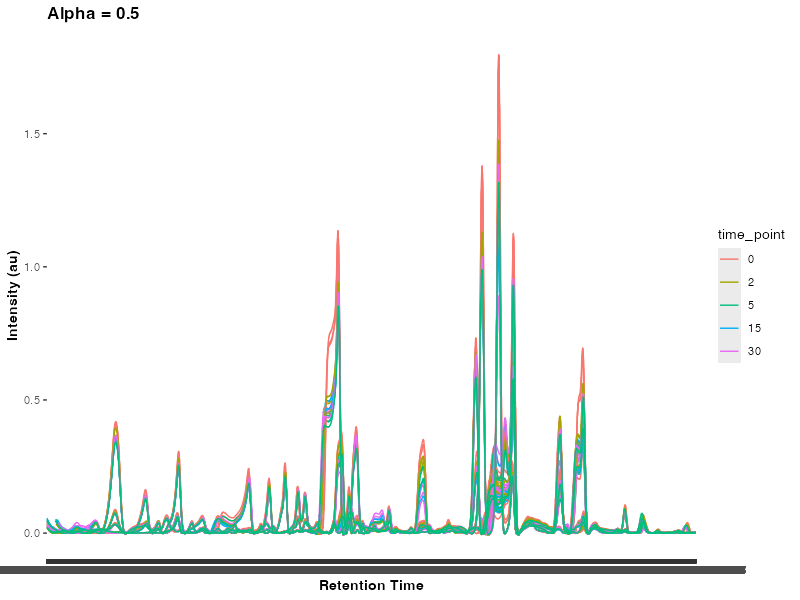

In [ ]:
Dataframe_0.5_long = wide_to_long(Dataframe_0.5)
plot_by_time(Dataframe_0.5_long, title = "Alpha = 0.5")

Warning message:
Removed 15378 rows containing missing values or values outside the scale range (`geom_line()`). 


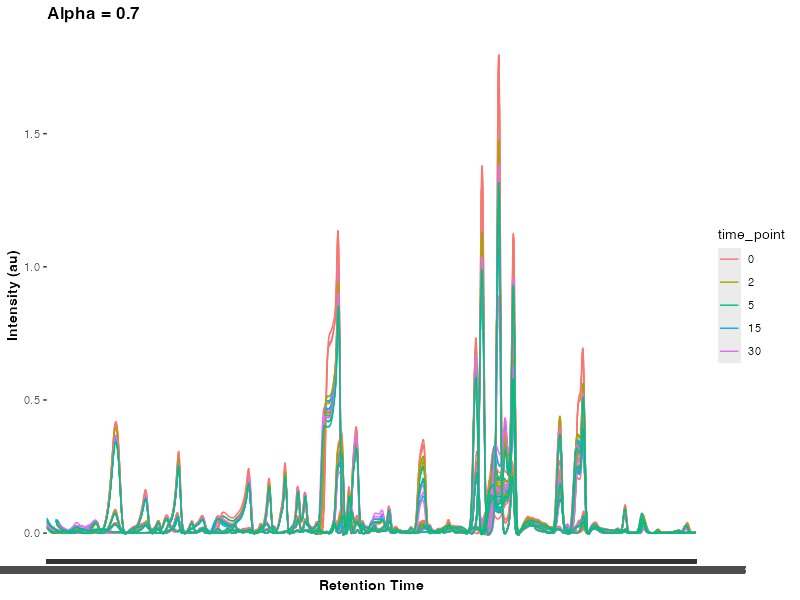

In [ ]:
Dataframe_0.7_long = wide_to_long(Dataframe_0.7)
plot_by_time(Dataframe_0.7_long, title = "Alpha = 0.7")

# Now lets do pca on one since they all look similar

In [13]:
pre_0.7 <- Dataframe_0.7 |> 
  mutate(across(where(is.numeric), ~replace_na(., 0.1)))

results <- pca(pre_0.7, center_in = TRUE, scale_in = TRUE)

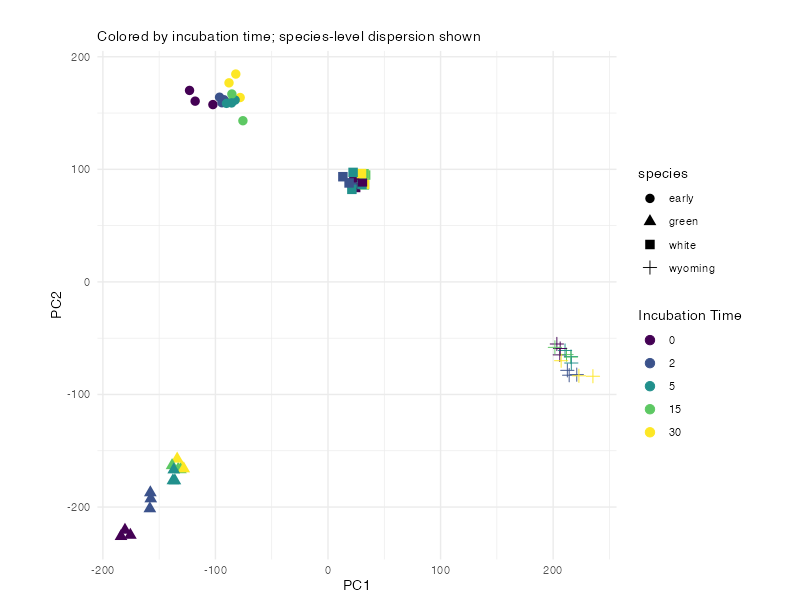

In [14]:
scores <- results$scores
plot_scores(scores, PC1, PC2)

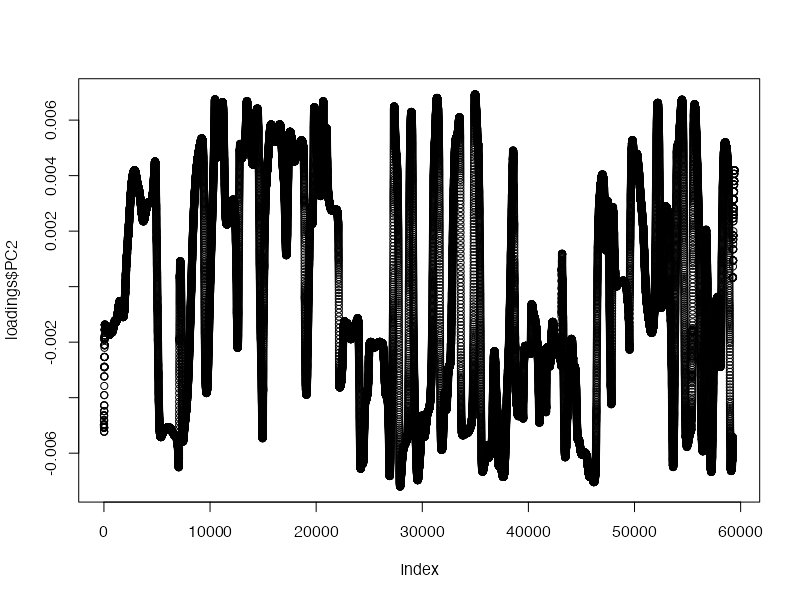

In [15]:
loadings <- results$loadings
plot(loadings$PC2)